In [3]:
# =============================================================================
# feature_markout_eda.ipynb -- visual EDA of feature vs 5s-markout relationships
# Goal: find NONLINEAR signal the ~0.03 Pearson correlations would miss.
# Run cell-by-cell in Jupyter.
# =============================================================================

# --- CELL 1: load a working sample into memory ---
# DuckDB for fast aggregation over the parquet store.
import duckdb
# pandas for the in-memory frame the plots consume.
import pandas as pd
# numpy for transforms (signed-log on OFI).
import numpy as np
# matplotlib for all static plots.
import matplotlib.pyplot as plt

# Feature-store root (outside the git project).
FS = "/Users/shazzak/Capital Stake - Results/feature_store"

# The features under investigation (same six as the correlation query).
FEATURES = ["obi_1", "micro_dev_bps", "toxicity", "ewma_trade_flow", "ofi_l1", "vpin"]
# The label we are trying to predict.
LABEL = "markout_5000ms_bps"

# Pull ONE symbol fully for detailed plots (PPL: 6.9M rows fits in memory as needed columns).
# We select only the columns we plot to keep it light.
cols = ", ".join(FEATURES + [LABEL, "markout_1000ms_bps", "markout_30000ms_bps", "time_since_trade_ms"])
# Query PPL rows with a valid 5s label (drop the ~2% near-close NaNs).
df = duckdb.sql(f"""
    SELECT {cols}
    FROM read_parquet('{FS}/PPL/*.parquet', hive_partitioning=true)
    WHERE {LABEL} IS NOT NULL
""").df()
# Report what we loaded.
print(f"PPL rows loaded: {len(df):,}")







PPL rows loaded: 6,803,715


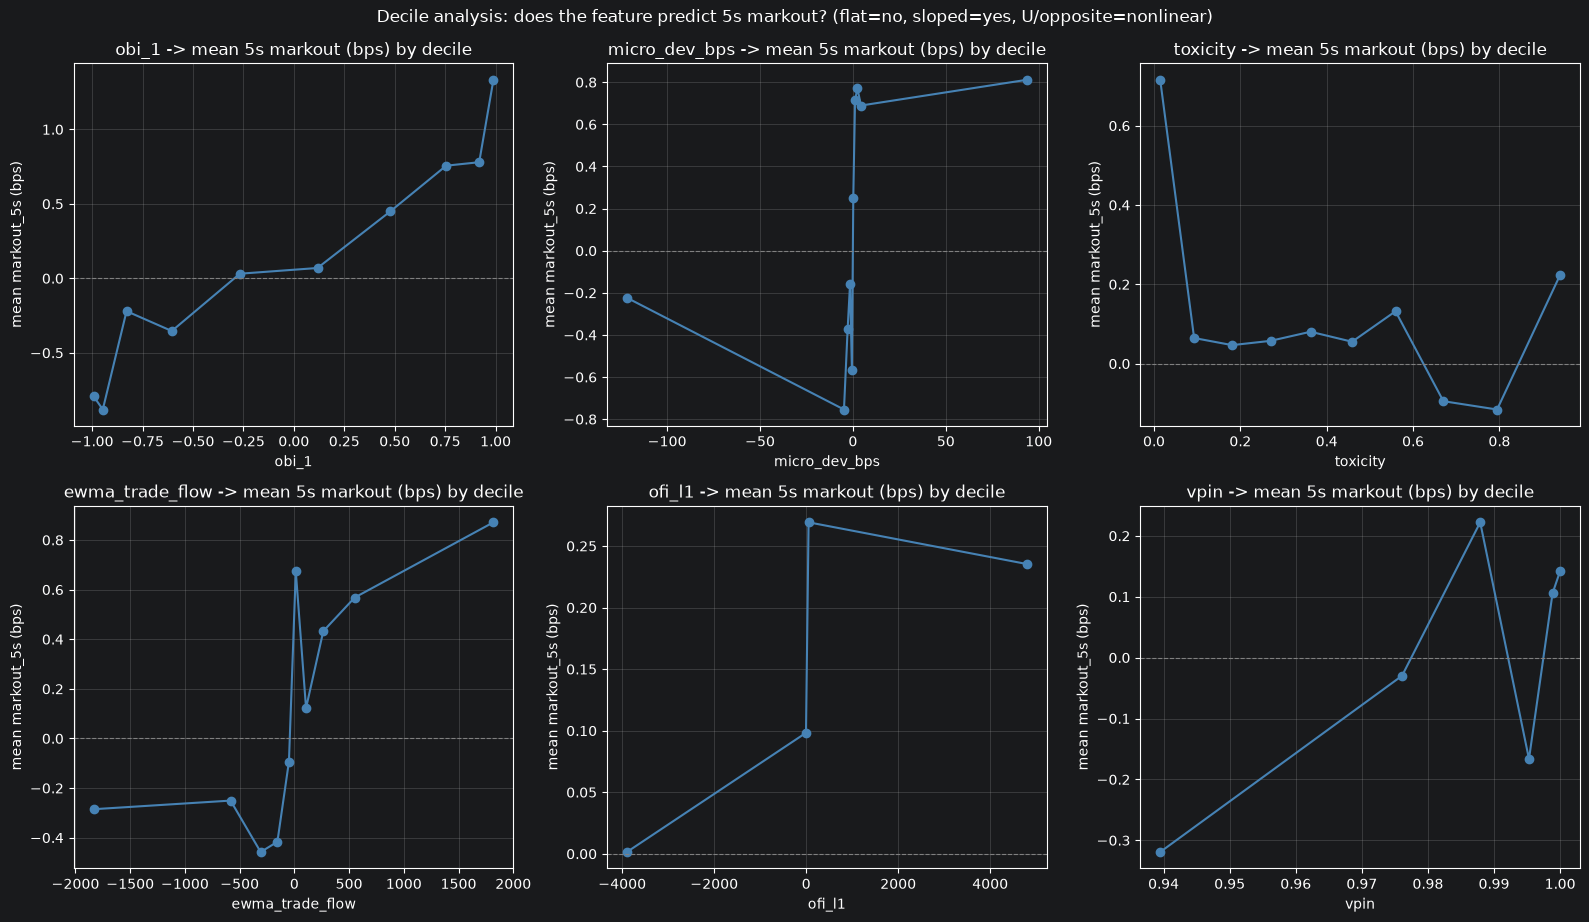

In [4]:

# --- CELL 2: decile plot -- THE key nonlinearity test ---
# For each feature, bin rows into deciles and plot mean markout per decile.
# A flat line = no signal. A monotone slope = linear signal. A U/hump/opposite
# slope = NONLINEAR or mean-reverting signal the Pearson corr missed.

# Create a 2x3 grid of subplots, one per feature.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
# Flatten the axes array so we can iterate linearly.
axes = axes.flatten()

# Loop each feature with its subplot.
for i, feat in enumerate(FEATURES):
    # Drop rows where this feature is NaN (VPIN is NaN before first bucket).
    sub = df[[feat, LABEL]].dropna()
    # Skip if nothing to plot.
    if len(sub) == 0:
        continue
    # Assign each row to a decile (1-10) of the feature. duplicates='drop'
    # guards against many identical values (e.g. ofi_l1=0) collapsing bins.
    sub["bucket"] = pd.qcut(sub[feat], 10, labels=False, duplicates="drop")
    # Group by bucket: mean feature value (x) and mean markout (y) per bucket.
    g = sub.groupby("bucket").agg(x=(feat, "mean"), y=(LABEL, "mean"),
                                  n=(LABEL, "size")).reset_index()
    # Plot mean markout vs mean feature per bucket, as connected points.
    axes[i].plot(g["x"], g["y"], "o-", color="steelblue")
    # Zero line: markout above 0 = price moved up after this feature value.
    axes[i].axhline(0, color="grey", lw=0.8, ls="--")
    # Label the subplot with the feature name.
    axes[i].set_title(f"{feat} -> mean 5s markout (bps) by decile")
    # X axis is the feature's mean per bucket.
    axes[i].set_xlabel(feat)
    # Y axis is mean forward markout in bps.
    axes[i].set_ylabel("mean markout_5s (bps)")
    # Light grid for readability.
    axes[i].grid(alpha=0.3)
# Tidy layout.
plt.tight_layout()
# Title the whole figure.
fig.suptitle("Decile analysis: does the feature predict 5s markout? (flat=no, sloped=yes, U/opposite=nonlinear)", y=1.02)
# Render.
plt.show()


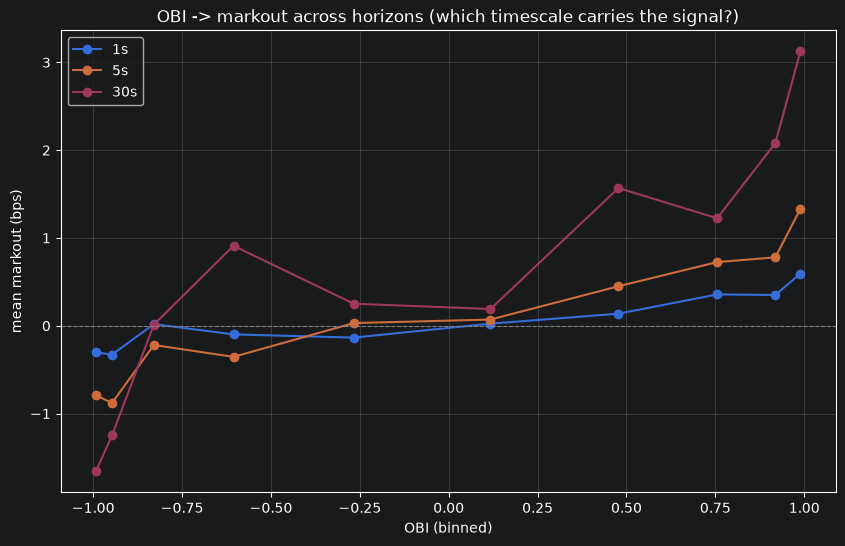

In [5]:

# --- CELL 3: OBI decile across THREE horizons -- is the signal at a different timescale? ---
# The 5s correlation was near zero; maybe the signal lives at 1s or 30s.

# One figure comparing horizons for the strongest feature (obi_1).
fig, ax = plt.subplots(figsize=(10, 6))
# Bin by OBI decile once.
tmp = df[["obi_1", "markout_1000ms_bps", LABEL, "markout_30000ms_bps"]].dropna()
# Assign OBI deciles.
tmp["bucket"] = pd.qcut(tmp["obi_1"], 10, labels=False, duplicates="drop")
# For each horizon, plot mean markout per OBI decile.
for hcol, lbl in [("markout_1000ms_bps", "1s"), (LABEL, "5s"), ("markout_30000ms_bps", "30s")]:
    # Mean OBI (x) and mean markout at this horizon (y) per bucket.
    g = tmp.groupby("bucket").agg(x=("obi_1", "mean"), y=(hcol, "mean")).reset_index()
    # Plot the horizon's curve.
    ax.plot(g["x"], g["y"], "o-", label=lbl)
# Zero reference.
ax.axhline(0, color="grey", lw=0.8, ls="--")
# Axis labels + legend.
ax.set_xlabel("OBI (binned)"); ax.set_ylabel("mean markout (bps)")
ax.set_title("OBI -> markout across horizons (which timescale carries the signal?)")
ax.legend(); ax.grid(alpha=0.3)
plt.show()




/var/folders/3t/g2vl3d955cvf84wtydtzs_5r0000gn/T/ipykernel_79446/625528243.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g[LABEL].values for _, g in samp.groupby("obi_bucket")]
/var/folders/3t/g2vl3d955cvf84wtydtzs_5r0000gn/T/ipykernel_79446/625528243.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  labels = [str(interval) for interval, _ in samp.groupby("obi_bucket")]


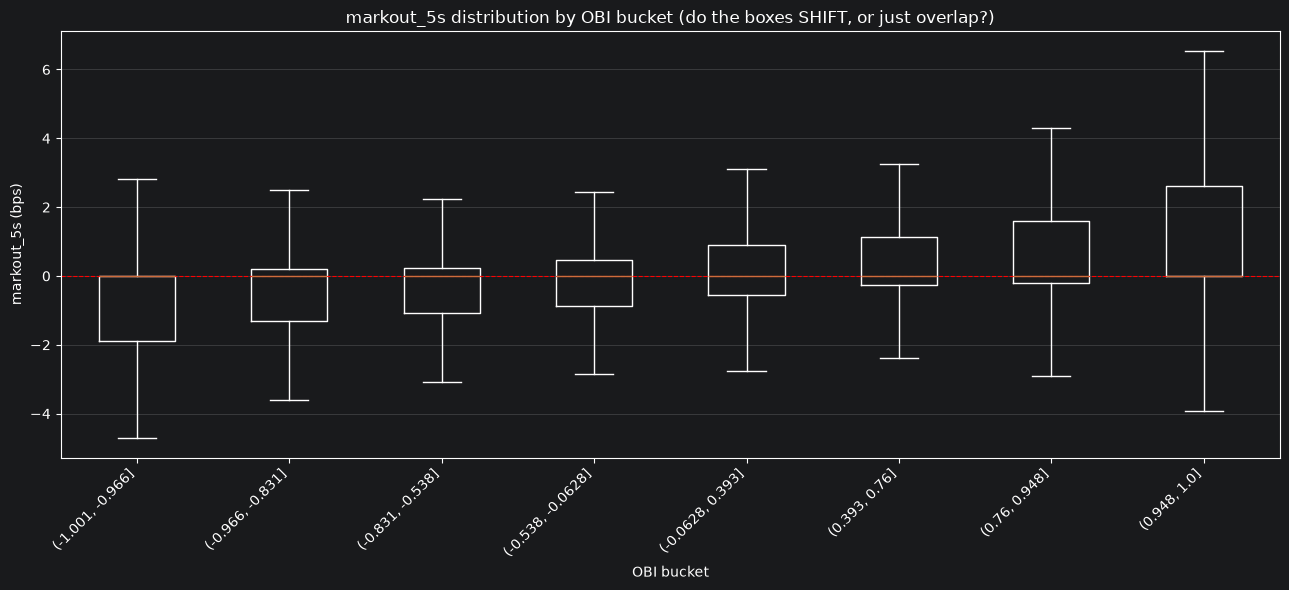

In [6]:

# --- CELL 4: box plots of markout by OBI bucket -- signal vs NOISE ---
# The decile MEAN might be nonzero but drowned in variance. Box plots show
# whether the DISTRIBUTION shifts, not just the mean. If boxes overlap
# completely, even a real mean-shift is unusable (too noisy to trade).

# Work on a manageable sample for box rendering (500k rows is plenty).
samp = df[["obi_1", LABEL]].dropna().sample(min(500_000, len(df)), random_state=0)
# Bin OBI into 8 labelled buckets for readable boxes.
samp["obi_bucket"] = pd.qcut(samp["obi_1"], 8, duplicates="drop")
# Build the figure.
fig, ax = plt.subplots(figsize=(13, 6))
# Group markout values by OBI bucket for the box plot.
groups = [g[LABEL].values for _, g in samp.groupby("obi_bucket")]
# Bucket labels for the x axis.
labels = [str(interval) for interval, _ in samp.groupby("obi_bucket")]
# Draw box plots; showfliers=False hides the extreme tails so the boxes are legible.
ax.boxplot(groups, showfliers=False)
# Zero reference.
ax.axhline(0, color="red", lw=0.8, ls="--")
# X ticks = OBI buckets (rotated to fit).
ax.set_xticklabels(labels, rotation=45, ha="right")
# Labels + title.
ax.set_ylabel("markout_5s (bps)"); ax.set_xlabel("OBI bucket")
ax.set_title("markout_5s distribution by OBI bucket (do the boxes SHIFT, or just overlap?)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()


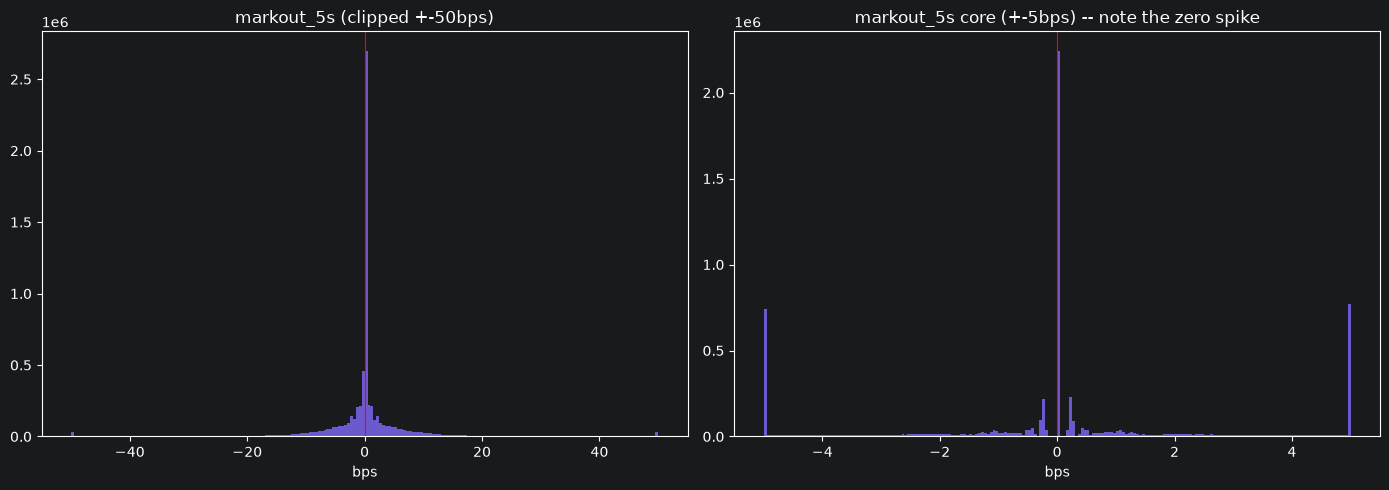

exactly-zero 5s markout: 32.9% of rows


In [7]:
# --- CELL 5: markout histogram -- understand the label's shape ---
# Before trusting any model, know the target distribution. HFT markout is
# fat-tailed and spiky at zero (many rows: no price change in 5s).

# Two-panel: full range (clipped) and zoomed core.
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
# Full-ish view, clipped to +-50bps so tails don't blow out the axis.
a1.hist(df[LABEL].clip(-50, 50), bins=200, color="slateblue")
a1.set_title("markout_5s (clipped +-50bps)"); a1.set_xlabel("bps"); a1.axvline(0, color="red", lw=0.8)
# Zoomed core to see the spike at zero.
a2.hist(df[LABEL].clip(-5, 5), bins=200, color="slateblue")
a2.set_title("markout_5s core (+-5bps) -- note the zero spike"); a2.set_xlabel("bps"); a2.axvline(0, color="red", lw=0.8)
# Render.
plt.tight_layout(); plt.show()
# Print how many rows have EXACTLY zero markout (no price move in 5s -- pure noise rows).
print(f"exactly-zero 5s markout: {(df[LABEL]==0).mean():.1%} of rows")


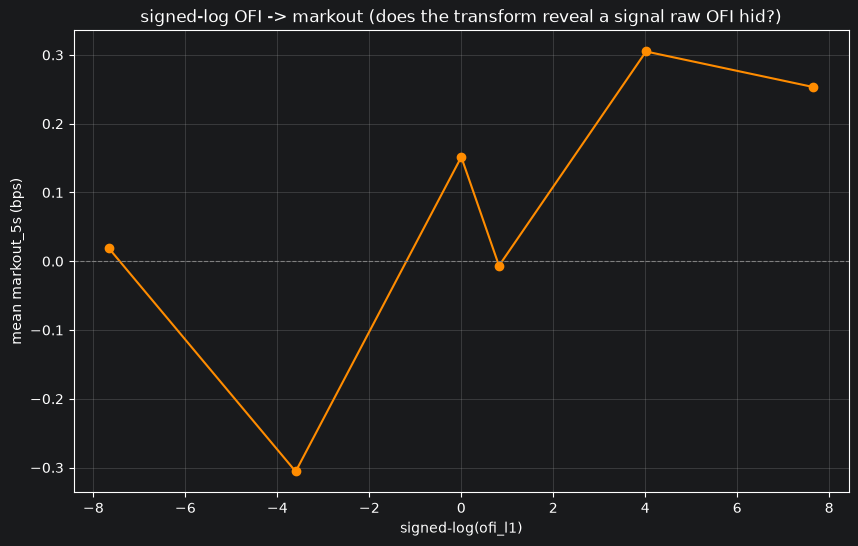

In [8]:

# --- CELL 6: signed-log OFI decile -- the heavy-tailed feature, transformed ---
# ofi_l1 has 447k outliers; raw correlation is meaningless. Signed-log first,
# THEN bin, to see if transformed OFI predicts markout.

# Signed-log transform: sign(x)*log(1+|x|), compresses the tail, keeps direction.
df["ofi_slog"] = np.sign(df["ofi_l1"]) * np.log1p(np.abs(df["ofi_l1"]))
# Drop NaNs for this pair.
sub = df[["ofi_slog", LABEL]].dropna()
# Decile-bin the transformed OFI.
sub["bucket"] = pd.qcut(sub["ofi_slog"], 12, labels=False, duplicates="drop")
# Mean transformed-OFI and mean markout per bucket.
g = sub.groupby("bucket").agg(x=("ofi_slog", "mean"), y=(LABEL, "mean")).reset_index()
# Plot.
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(g["x"], g["y"], "o-", color="darkorange")
ax.axhline(0, color="grey", lw=0.8, ls="--")
ax.set_xlabel("signed-log(ofi_l1)"); ax.set_ylabel("mean markout_5s (bps)")
ax.set_title("signed-log OFI -> markout (does the transform reveal a signal raw OFI hid?)")
ax.grid(alpha=0.3)
plt.show()



trade-conditioned rows (<100ms since trade): 2,101,810


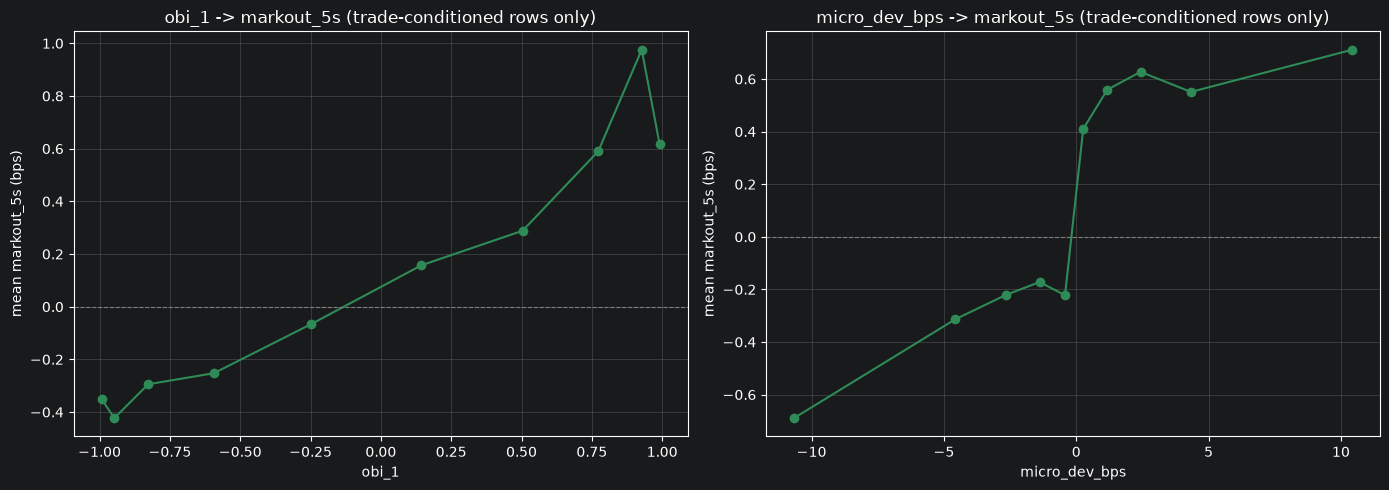

In [9]:

# --- CELL 7: trade-conditioned deciles -- signal on INFORMATIVE rows only ---
# 6.9M rows are mostly jitter. Restrict to rows right after a trade and re-bin.

# Rows within 100ms of a trade (something just happened).
evt = df[df["time_since_trade_ms"] < 100][["obi_1", "micro_dev_bps", LABEL]].dropna()
# Report how many informative rows remain.
print(f"trade-conditioned rows (<100ms since trade): {len(evt):,}")
# Two-panel decile plot for OBI and micro_dev on these rows.
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
# OBI decile on event rows.
for ax, feat in [(a1, "obi_1"), (a2, "micro_dev_bps")]:
    e = evt[[feat, LABEL]].dropna()
    e["bucket"] = pd.qcut(e[feat], 10, labels=False, duplicates="drop")
    g = e.groupby("bucket").agg(x=(feat, "mean"), y=(LABEL, "mean")).reset_index()
    ax.plot(g["x"], g["y"], "o-", color="seagreen")
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.set_title(f"{feat} -> markout_5s (trade-conditioned rows only)")
    ax.set_xlabel(feat); ax.set_ylabel("mean markout_5s (bps)"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()